# Понижение размерности

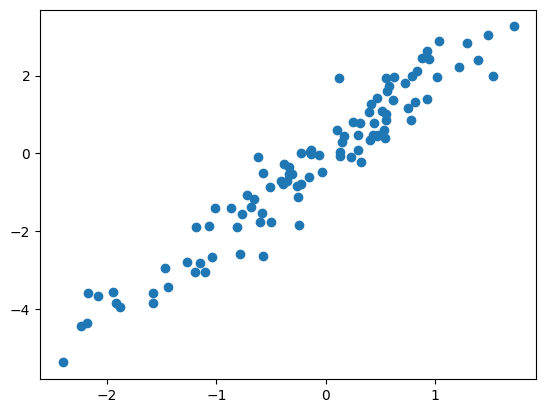

In [151]:
import numpy as np
import matplotlib.pyplot as plt

n_samples = 100
x = np.random.normal(0, 1, n_samples)  # Первый признак
y = 2 * x + np.random.normal(0, 0.5, n_samples)  # Второй признак (коррелирован с первым)

X = np.column_stack((x, y))

plt.scatter(x, y)
plt.show()

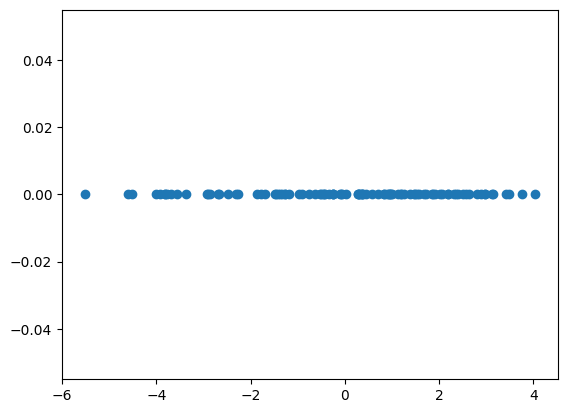

In [152]:
from sklearn.decomposition import PCA

pca = PCA(n_components=1)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:, 0], np.zeros_like(X_pca[:, 0]))

In [153]:
print(f"Главная компонента (направление): {pca.components_}")
print(f"Объясненная дисперсия: {pca.explained_variance_ratio_}")

Главная компонента (направление): [[0.41890329 0.90803086]]
Объясненная дисперсия: [0.98918699]


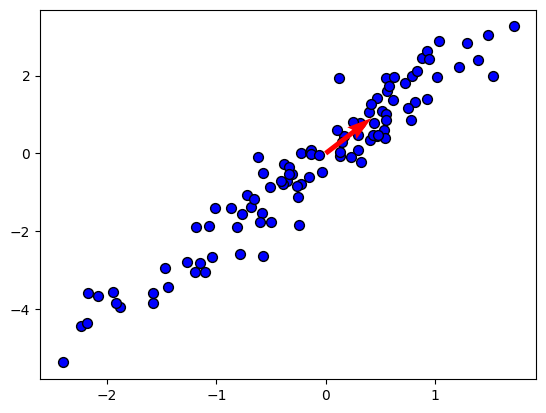

In [154]:
plt.scatter(X[:, 0], X[:, 1], c='blue', edgecolor='k', s=50)
pc1_direction = pca.components_[0]
plt.quiver(0, 0, pc1_direction[0], pc1_direction[1], angles='xy', scale_units='xy', scale=1, color='red', width=0.01)

In [155]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

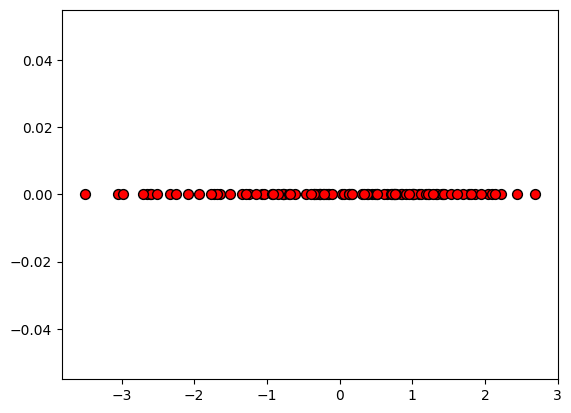

In [156]:
pca = PCA(n_components=1)
X_pca = pca.fit_transform(X_scaled)

plt.scatter(X_pca, np.zeros_like(X_pca), c='red', edgecolor='k', s=50)

In [157]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X = data.data
y = data.target
X.shape

(569, 30)

In [158]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)  # Уменьшаем до 2 компонент
X_pca = pca.fit_transform(X_scaled)

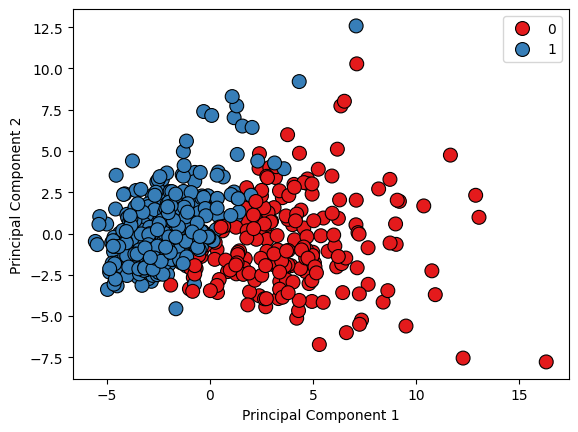

In [159]:
import seaborn as sns

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='Set1', edgecolor='k', s=100)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

In [160]:
print(f"Главная компонента (направление): {pca.components_}")

Главная компонента (направление): [[ 0.21890244  0.10372458  0.22753729  0.22099499  0.14258969  0.23928535
   0.25840048  0.26085376  0.13816696  0.06436335  0.20597878  0.01742803
   0.21132592  0.20286964  0.01453145  0.17039345  0.15358979  0.1834174
   0.04249842  0.10256832  0.22799663  0.10446933  0.23663968  0.22487053
   0.12795256  0.21009588  0.22876753  0.25088597  0.12290456  0.13178394]
 [-0.23385713 -0.05970609 -0.21518136 -0.23107671  0.18611302  0.15189161
   0.06016536 -0.0347675   0.19034877  0.36657547 -0.10555215  0.08997968
  -0.08945723 -0.15229263  0.20443045  0.2327159   0.19720728  0.13032156
   0.183848    0.28009203 -0.21986638 -0.0454673  -0.19987843 -0.21935186
   0.17230435  0.14359317  0.09796411 -0.00825724  0.14188335  0.27533947]]


In [161]:
explained_variance = pca.explained_variance_ratio_
print(f"Объясненная дисперсия каждой компоненты: {explained_variance}")
print(f"Суммарная объясненная дисперсия: {sum(explained_variance):.2f}")

Объясненная дисперсия каждой компоненты: [0.44272026 0.18971182]
Суммарная объясненная дисперсия: 0.63


In [162]:
n_components_range = range(1, 31)
explained_variance = []

In [163]:
for n in n_components_range:
    pca = PCA(n_components=n)
    pca.fit(X_scaled)
    explained_variance.append(sum(pca.explained_variance_ratio_))

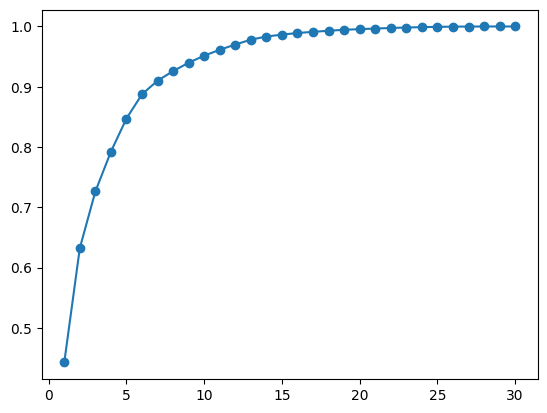

In [164]:
plt.plot(n_components_range, explained_variance, marker='o')
plt.show()

In [165]:
pca = PCA(n_components=7)  # Уменьшаем до 7 компонент
X_pca = pca.fit_transform(X_scaled)

# Объясненная дисперсия
explained_variance = pca.explained_variance_ratio_
print(f"Объясненная дисперсия каждой компоненты: {explained_variance}")
print(f"Суммарная объясненная дисперсия: {sum(explained_variance):.2f}")

Объясненная дисперсия каждой компоненты: [0.44272026 0.18971182 0.09393163 0.06602135 0.05495768 0.04024522
 0.02250734]
Суммарная объясненная дисперсия: 0.91


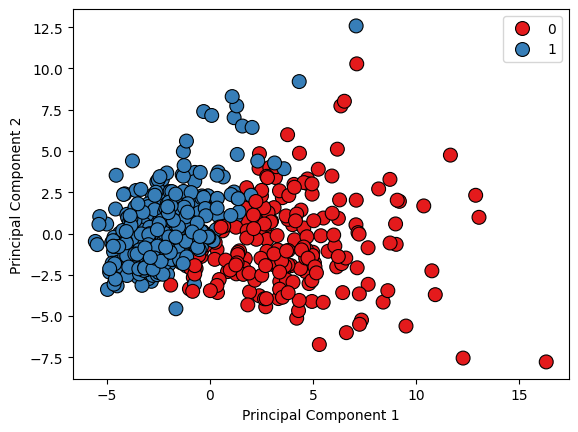

In [166]:
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette='Set1', edgecolor='k', s=100)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()
# identical to the previous one

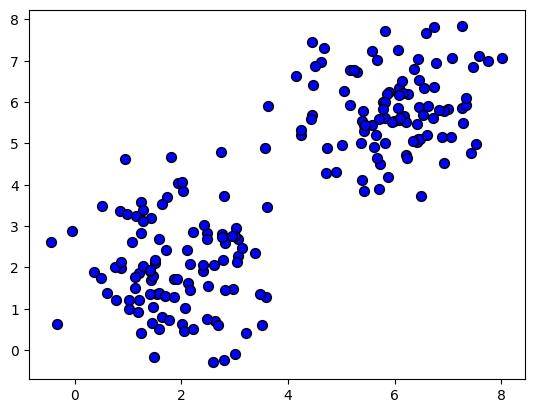

In [167]:
n_samples = 100

x1 = np.random.normal(2, 1, n_samples)
y1 = np.random.normal(2, 1, n_samples)
x2 = np.random.normal(6, 1, n_samples)
y2 = np.random.normal(6, 1, n_samples)

X = np.vstack((np.column_stack((x1, y1)), np.column_stack((x2, y2))))
y = np.hstack((np.zeros(n_samples), np.ones(n_samples)))
plt.scatter(X[:, 0], X[:, 1], c='blue', edgecolor='k', s=50)
plt.show()

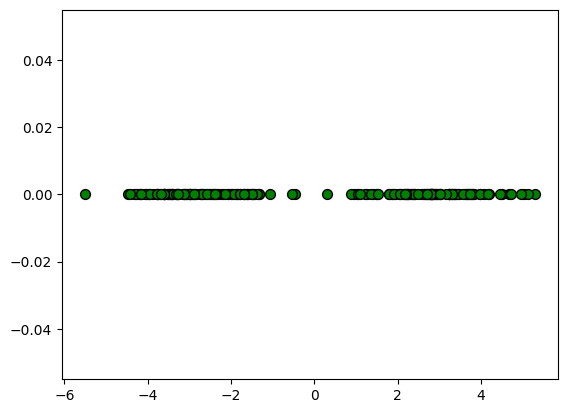

In [168]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lda = LDA(n_components=1)
X_lda = lda.fit_transform(X_scaled, y)
plt.scatter(X_lda, np.zeros_like(X_lda), c='green', edgecolor='k', s=50)
plt.show()

In [169]:
print(f"Коэффициенты LDA: {lda.coef_}")

Коэффициенты LDA: [[10.63928633  7.27597056]]


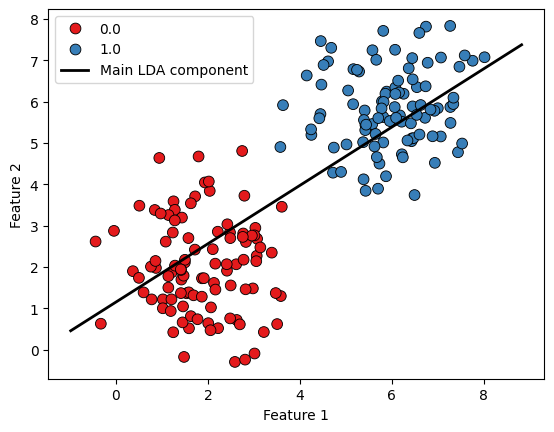

In [170]:
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette="Set1", edgecolor="k", s=60)

lda_direction = lda.coef_[0] / scaler.scale_
lda_direction = lda_direction / np.linalg.norm(lda_direction)

center = X.mean(axis=0)
t = np.linspace(-6, 6, 200)
line = center + np.outer(t, lda_direction)

plt.plot(line[:, 0], line[:, 1], color="black", linewidth=2, label="Main LDA component")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

In [171]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=200, random_state=170, centers=2)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X = np.dot(X, transformation) 

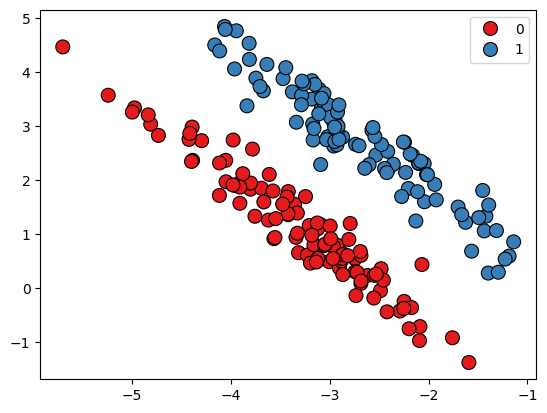

In [172]:
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette='Set1', edgecolor='k', s=100)
plt.show()

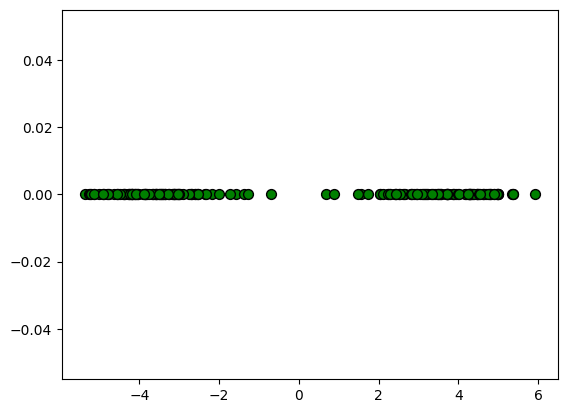

In [173]:
lda = LDA(n_components=1)
X_lda = lda.fit_transform(X, y)
plt.scatter(X_lda, np.zeros_like(X_lda), c='green', edgecolor='k', s=50)
plt.show()

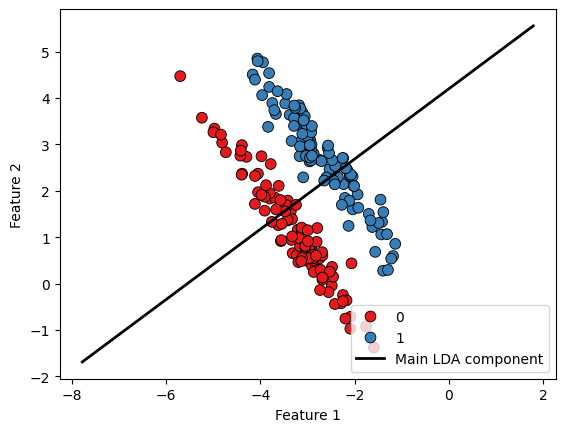

In [174]:
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette="Set1", edgecolor="k", s=60)

lda_direction = lda.coef_[0] / scaler.scale_
lda_direction = lda_direction / np.linalg.norm(lda_direction)

center = X.mean(axis=0)
t = np.linspace(-6, 6, 200)
line = center + np.outer(t, lda_direction)

plt.plot(line[:, 0], line[:, 1], color="black", linewidth=2, label="Main LDA component")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

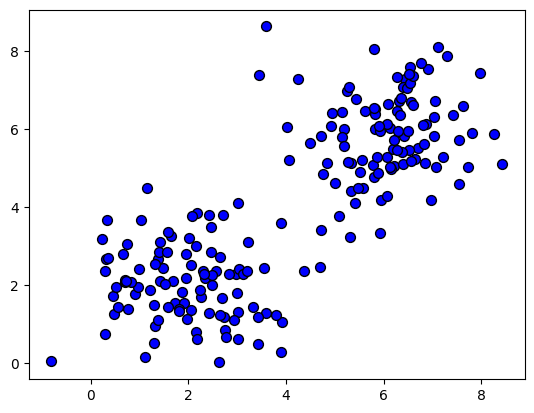

In [175]:
n_samples = 100

x1 = np.random.normal(2, 1, n_samples)
y1 = np.random.normal(2, 1, n_samples)
x2 = np.random.normal(6, 1, n_samples)
y2 = np.random.normal(6, 1, n_samples)

X = np.vstack((np.column_stack((x1, y1)), np.column_stack((x2, y2))))
y = np.hstack((np.zeros(n_samples), np.ones(n_samples)))
plt.scatter(X[:, 0], X[:, 1], c='blue', edgecolor='k', s=50)
plt.show()

In [176]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=1, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

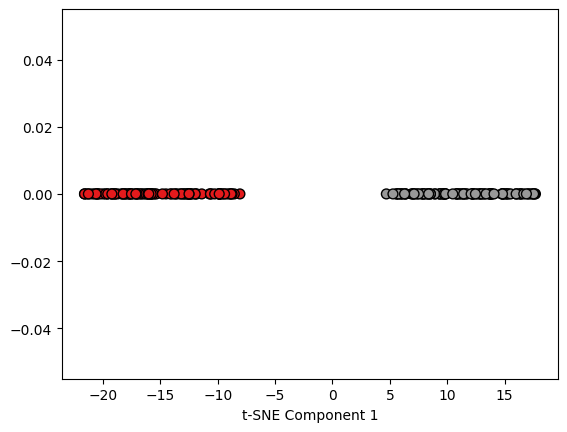

In [177]:
plt.scatter(X_tsne[:, 0], np.zeros_like(X_tsne[:, 0]), c=y, cmap='Set1', edgecolor='k', s=50)
plt.xlabel('t-SNE Component 1')
plt.ylabel('')
plt.show()

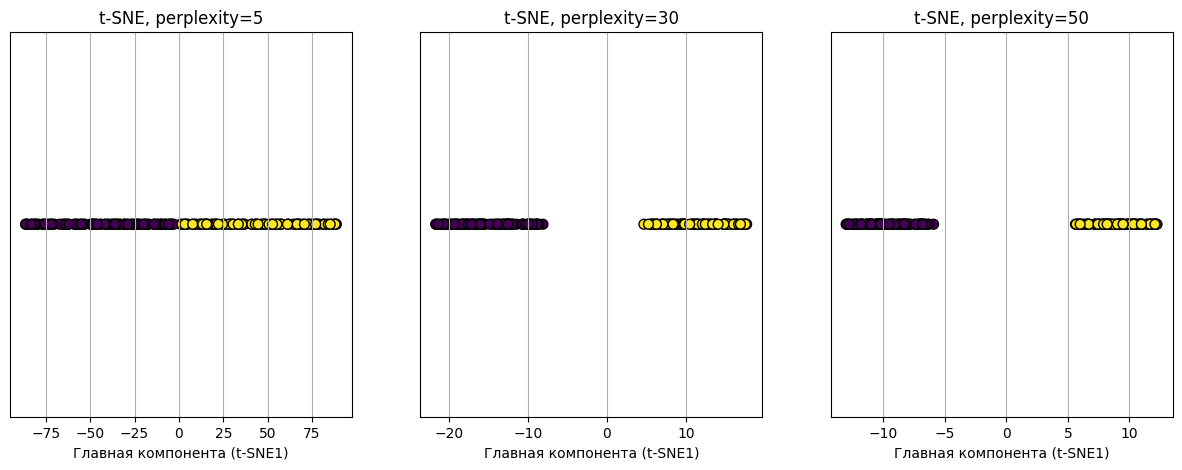

In [178]:
perplexity_values = [5, 30, 50]
plt.figure(figsize=(15, 5))
for i, perplexity in enumerate(perplexity_values):
    tsne = TSNE(n_components=1, perplexity=perplexity, random_state=42)
    X_tsne = tsne.fit_transform(X_scaled)

    plt.subplot(1, 3, i+1)
    plt.scatter(X_tsne, np.zeros_like(X_tsne), c=y, cmap='viridis', edgecolor='k', s=50)
    plt.title(f't-SNE, perplexity={perplexity}')
    plt.xlabel('Главная компонента (t-SNE1)')
    plt.yticks([])
    plt.grid(True)

In [179]:
from sklearn.datasets import make_circles
X, y = make_circles(n_samples=500, factor=0.3, noise=0.05, random_state=42)

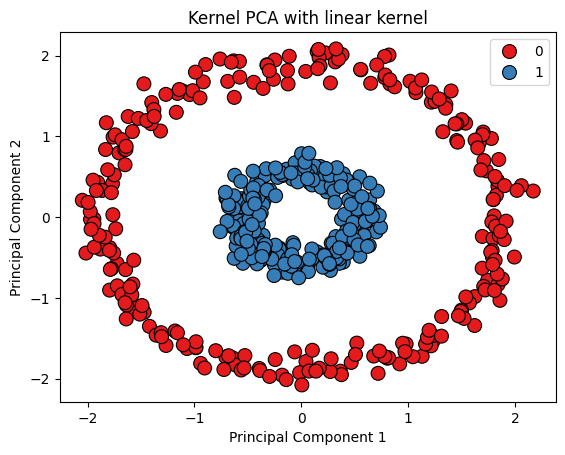

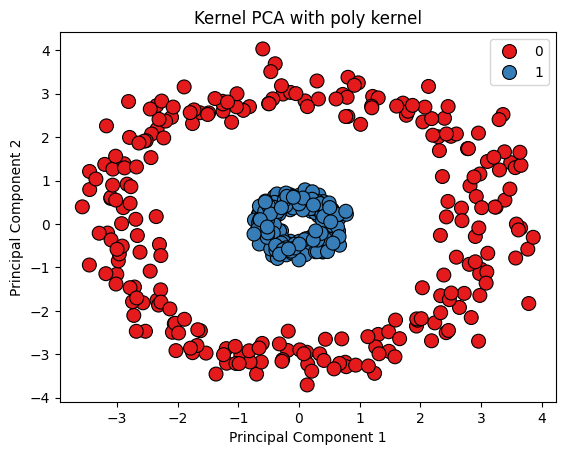

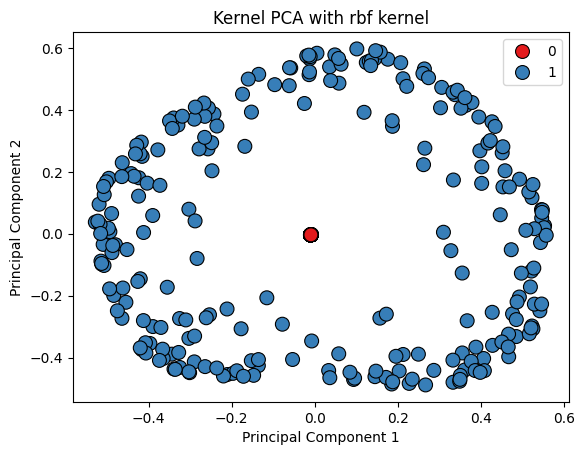

In [180]:
from sklearn.decomposition import KernelPCA
kernels = ['linear', 'poly', 'rbf']
for kernel in kernels:
    kpca = KernelPCA(n_components=2, kernel=kernel, gamma=10 if kernel == 'rbf' else None)
    X_kpca = kpca.fit_transform(X_scaled)
    X_scaled = scaler.fit_transform(X)
    X_kpca = kpca.fit_transform(X_scaled)

    sns.scatterplot(
        x=X_kpca[:, 0],
        y=X_kpca[:, 1],
        hue=y,
        palette='Set1',
        edgecolor='k',
        s=100
    )
    plt.title(f'Kernel PCA with {kernel} kernel')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.show()

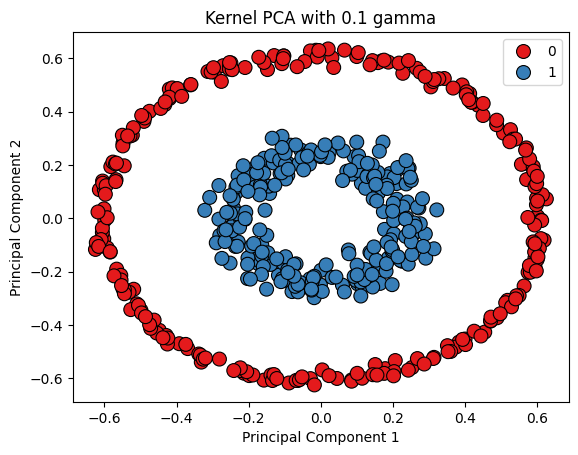

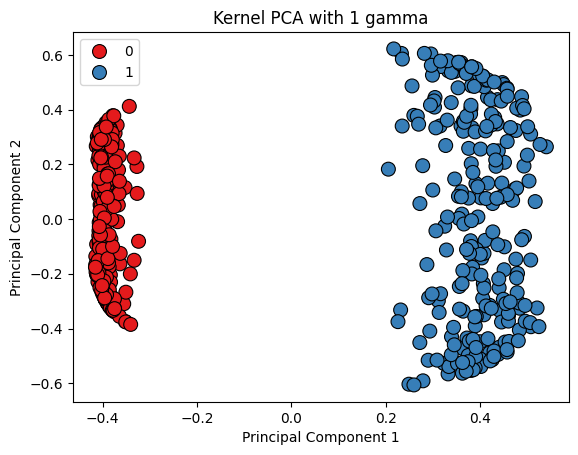

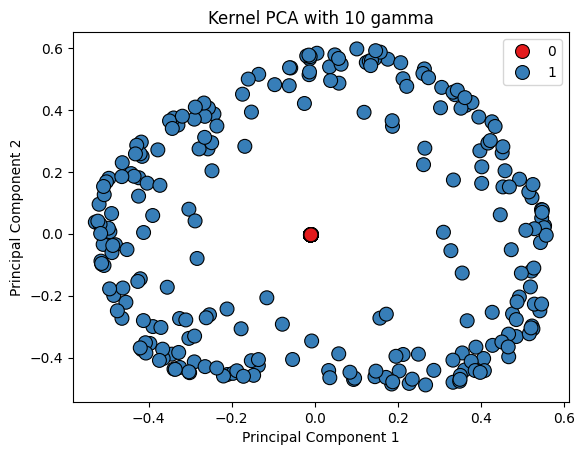

In [181]:
gamma_values = [0.1, 1, 10]
for gamma in gamma_values:
    kpca = KernelPCA(n_components=2, kernel='rbf', gamma=gamma)
    X_kpca = kpca.fit_transform(X_scaled)
    X_scaled = scaler.fit_transform(X)
    X_kpca = kpca.fit_transform(X_scaled)

    sns.scatterplot(
        x=X_kpca[:, 0],
        y=X_kpca[:, 1],
        hue=y,
        palette='Set1',
        edgecolor='k',
        s=100
    )
    plt.title(f'Kernel PCA with {gamma} gamma')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.show()

## Задания для самостоятельного выполнения

#### 1. Попробуйте изменить уровень шума в данных (например, увеличить или уменьшить шум в y) и посмотрите, как это влияет на результат PCA.

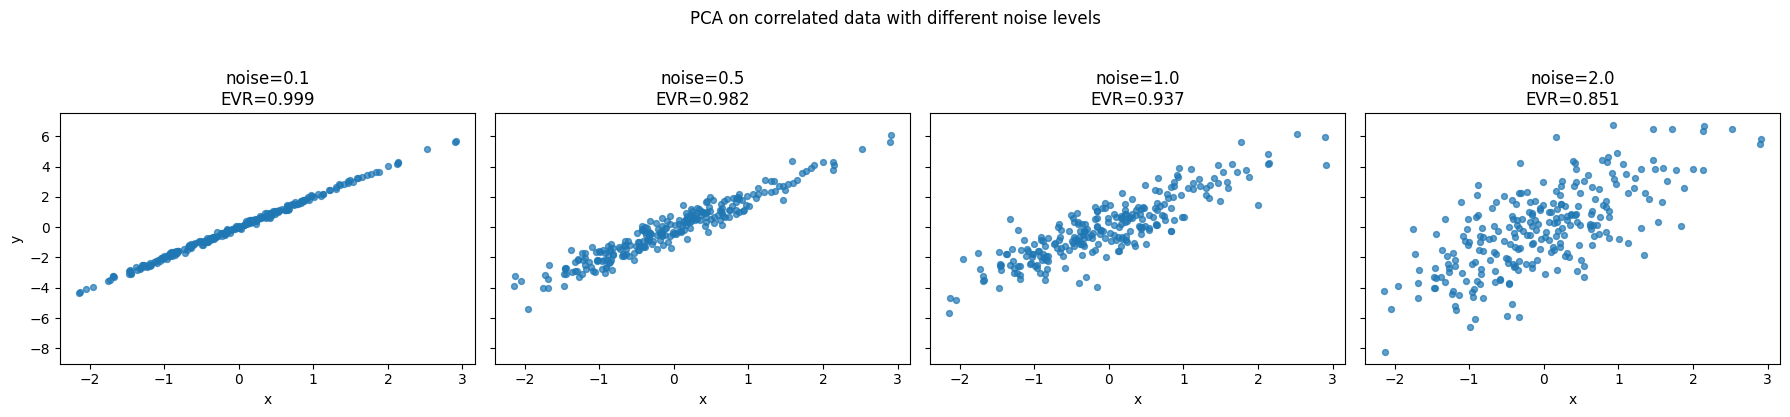

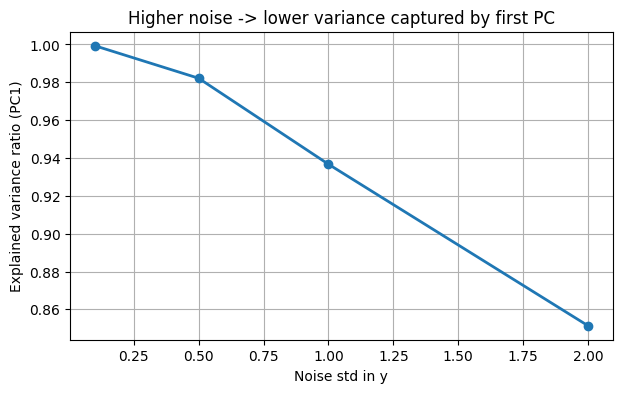

noise=0.1: PC1 explained variance = 0.999
noise=0.5: PC1 explained variance = 0.982
noise=1.0: PC1 explained variance = 0.937
noise=2.0: PC1 explained variance = 0.851


In [182]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

rng = np.random.default_rng(42)
n_samples = 250
x = rng.normal(0, 1, n_samples)
noise_levels = [0.1, 0.5, 1.0, 2.0]

explained = []

fig, axes = plt.subplots(1, len(noise_levels), figsize=(18, 4), sharex=True, sharey=True)
for i, noise_std in enumerate(noise_levels):
    y = 2 * x + rng.normal(0, noise_std, n_samples)
    X_noise = np.column_stack([x, y])

    X_scaled_noise = StandardScaler().fit_transform(X_noise)
    pca_noise = PCA(n_components=1)
    X_noise_pca = pca_noise.fit_transform(X_scaled_noise)

    explained_ratio = pca_noise.explained_variance_ratio_[0]
    explained.append(explained_ratio)

    axes[i].scatter(X_noise[:, 0], X_noise[:, 1], s=18, alpha=0.7)
    axes[i].set_title(f"noise={noise_std}\nEVR={explained_ratio:.3f}")
    axes[i].set_xlabel("x")
    if i == 0:
        axes[i].set_ylabel("y")

plt.suptitle("PCA on correlated data with different noise levels", y=1.03)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(noise_levels, explained, marker="o", linewidth=2)
plt.xlabel("Noise std in y")
plt.ylabel("Explained variance ratio (PC1)")
plt.title("Higher noise -> lower variance captured by first PC")
plt.grid(True)
plt.show()

for nl, evr in zip(noise_levels, explained):
    print(f"noise={nl:>3}: PC1 explained variance = {evr:.3f}")

#### 2. Добавьте третий признак, который также коррелирует с первыми двумя, и примените PCA с n_components=2.

Explained variance ratio by 2 PCs: [0.94708327 0.04903336]
Total explained variance: 0.996


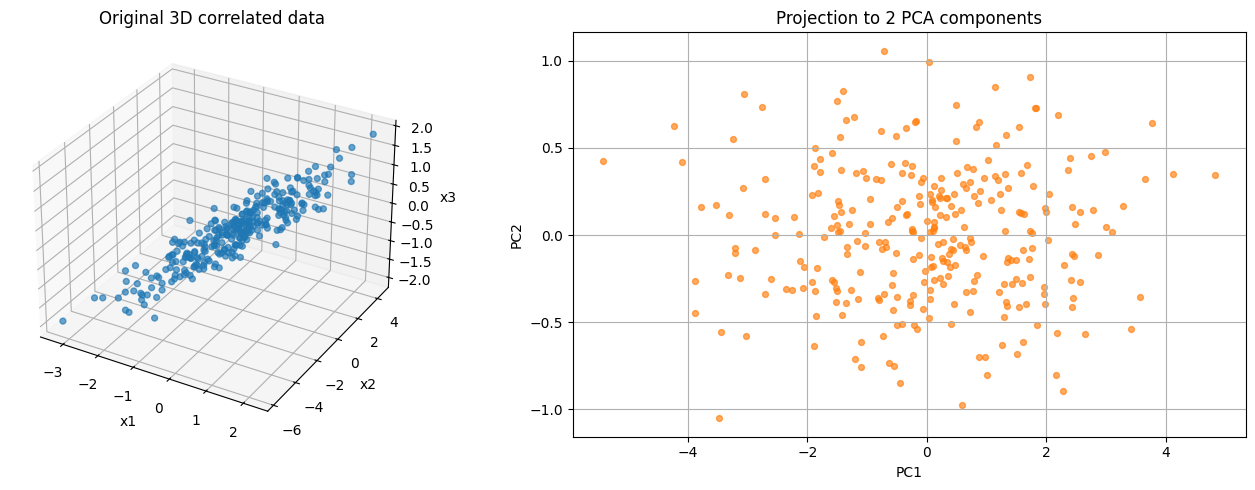

In [183]:
rng = np.random.default_rng(7)
n_samples = 300
x1 = rng.normal(0, 1, n_samples)
x2 = 1.8 * x1 + rng.normal(0, 0.35, n_samples)
x3 = -0.6 * x1 + 0.7 * x2 + rng.normal(0, 0.25, n_samples)
X3 = np.column_stack([x1, x2, x3])

X3_scaled = StandardScaler().fit_transform(X3)
pca_3d = PCA(n_components=2)
X3_pca2 = pca_3d.fit_transform(X3_scaled)

print("Explained variance ratio by 2 PCs:", pca_3d.explained_variance_ratio_)
print(f"Total explained variance: {pca_3d.explained_variance_ratio_.sum():.3f}")

fig = plt.figure(figsize=(14, 5))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.scatter(X3[:, 0], X3[:, 1], X3[:, 2], alpha=0.65, s=18)
ax1.set_title("Original 3D correlated data")
ax1.set_xlabel("x1")
ax1.set_ylabel("x2")
ax1.set_zlabel("x3")

ax2 = fig.add_subplot(1, 2, 2)
ax2.scatter(X3_pca2[:, 0], X3_pca2[:, 1], alpha=0.65, s=18, color="tab:orange")
ax2.set_title("Projection to 2 PCA components")
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.grid(True)

plt.tight_layout()
plt.show()

#### 3. Попробуйте изменить расположение классов (например, сделать их ближе друг к другу) и посмотрите, как это влияет на результат LDA.

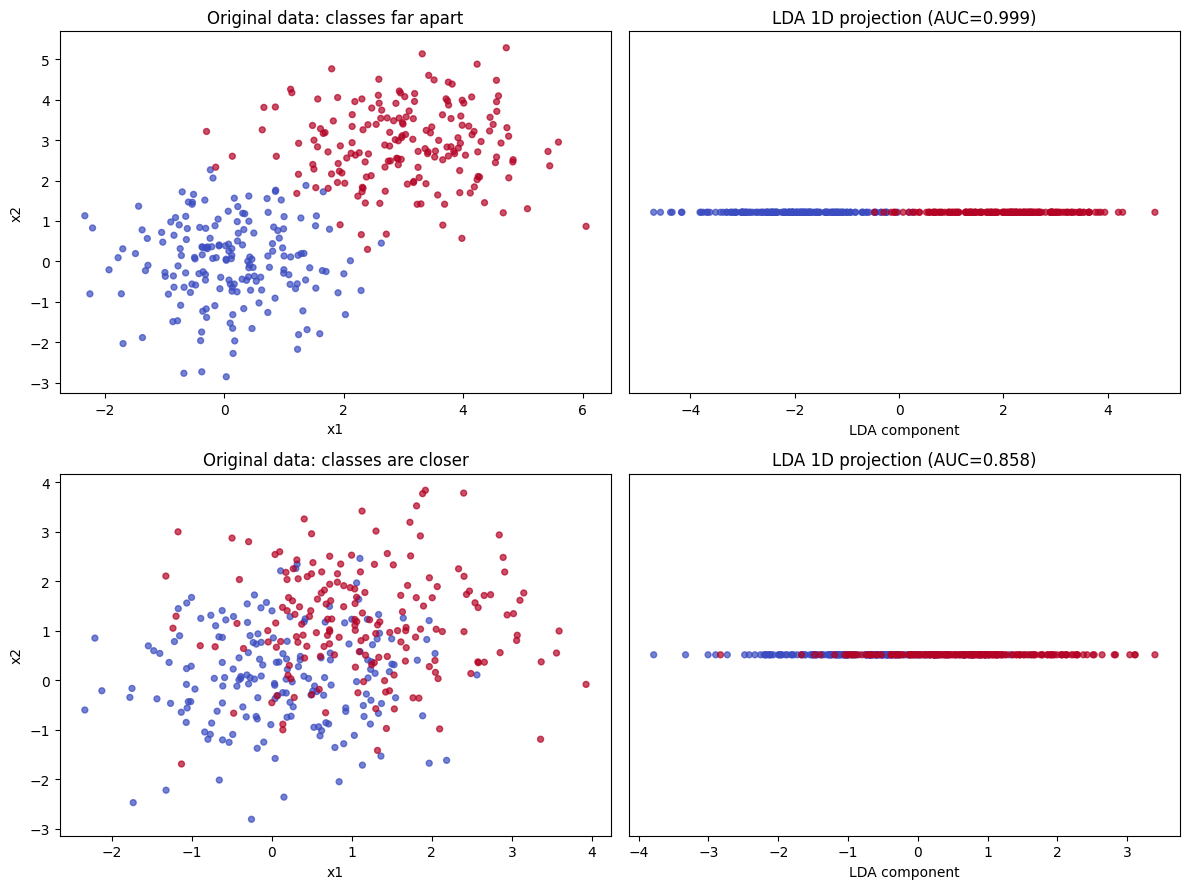

Scenario A (far classes) AUC:   0.999
Scenario B (close classes) AUC: 0.858


In [184]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import roc_auc_score

rng = np.random.default_rng(123)
n = 180

# well separated classes
X1_a = rng.normal(loc=[0, 0], scale=[1.0, 1.0], size=(n, 2))
X2_a = rng.normal(loc=[3.0, 3.0], scale=[1.0, 1.0], size=(n, 2))
Xa = np.vstack([X1_a, X2_a])
ya = np.hstack([np.zeros(n), np.ones(n)])

# classes moved closer
X1_b = rng.normal(loc=[0, 0], scale=[1.0, 1.0], size=(n, 2))
X2_b = rng.normal(loc=[1.2, 1.2], scale=[1.0, 1.0], size=(n, 2))
Xb = np.vstack([X1_b, X2_b])
yb = np.hstack([np.zeros(n), np.ones(n)])

def lda_projection_quality(X_local, y_local):
    X_scaled_local = StandardScaler().fit_transform(X_local)
    lda_local = LDA(n_components=1)
    z = lda_local.fit_transform(X_scaled_local, y_local).ravel()
    auc = roc_auc_score(y_local, z)
    # AUC can be below 0.5 if direction is flipped, i care about separability here
    auc = max(auc, 1 - auc)
    return z, auc

za, auc_a = lda_projection_quality(Xa, ya)
zb, auc_b = lda_projection_quality(Xb, yb)

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

axes[0, 0].scatter(Xa[:, 0], Xa[:, 1], c=ya, cmap="coolwarm", s=18, alpha=0.7)
axes[0, 0].set_title("Original data: classes far apart")
axes[0, 0].set_xlabel("x1")
axes[0, 0].set_ylabel("x2")

axes[0, 1].scatter(za, np.zeros_like(za), c=ya, cmap="coolwarm", s=18, alpha=0.7)
axes[0, 1].set_title(f"LDA 1D projection (AUC={auc_a:.3f})")
axes[0, 1].set_xlabel("LDA component")
axes[0, 1].set_yticks([])

axes[1, 0].scatter(Xb[:, 0], Xb[:, 1], c=yb, cmap="coolwarm", s=18, alpha=0.7)
axes[1, 0].set_title("Original data: classes are closer")
axes[1, 0].set_xlabel("x1")
axes[1, 0].set_ylabel("x2")

axes[1, 1].scatter(zb, np.zeros_like(zb), c=yb, cmap="coolwarm", s=18, alpha=0.7)
axes[1, 1].set_title(f"LDA 1D projection (AUC={auc_b:.3f})")
axes[1, 1].set_xlabel("LDA component")
axes[1, 1].set_yticks([])

plt.tight_layout()
plt.show()

print(f"Scenario A (far classes) AUC:   {auc_a:.3f}")
print(f"Scenario B (close classes) AUC: {auc_b:.3f}")
# при сближении классов, перекрытие в прогнозе LDA увеличивается

#### 4. Добавьте третий класс и примените LDA с n_components=2.

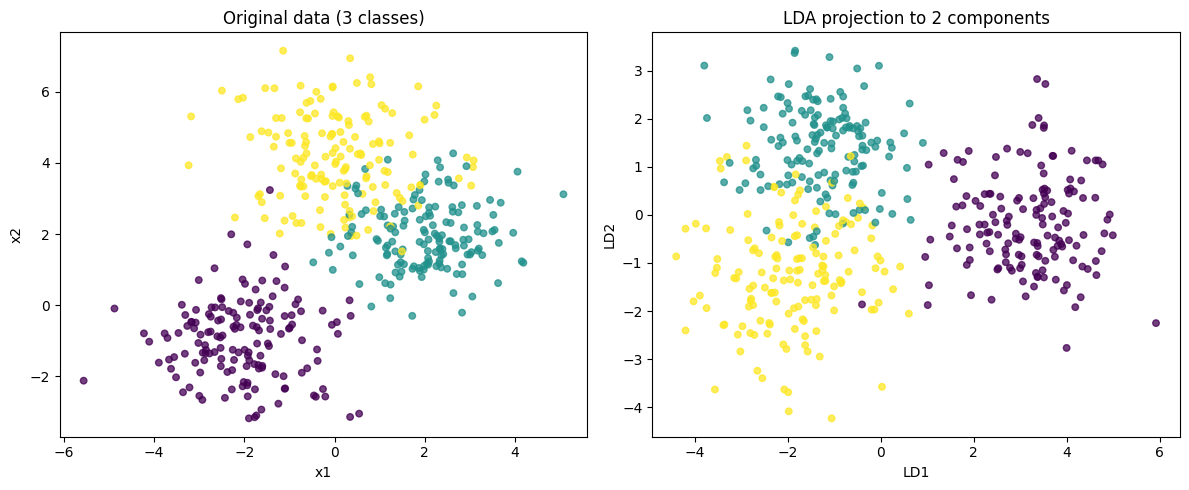

Class means in LDA space:
class 0: LD1=3.15, LD2=-0.18
class 1: LD1=-1.25, LD2=1.39
class 2: LD1=-1.90, LD2=-1.22


In [185]:
from sklearn.datasets import make_blobs
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

X3c, y3c = make_blobs(
    n_samples=450,
    centers=[[-2, -1], [2, 2], [0, 4]],
    cluster_std=[1.1, 1.0, 1.2],
    random_state=42,
)

X3c_scaled = StandardScaler().fit_transform(X3c)
lda_3c = LDA(n_components=2)
X3c_lda2 = lda_3c.fit_transform(X3c_scaled, y3c)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X3c[:, 0], X3c[:, 1], c=y3c, cmap="viridis", s=22, alpha=0.75)
axes[0].set_title("Original data (3 classes)")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")

axes[1].scatter(X3c_lda2[:, 0], X3c_lda2[:, 1], c=y3c, cmap="viridis", s=22, alpha=0.75)
axes[1].set_title("LDA projection to 2 components")
axes[1].set_xlabel("LD1")
axes[1].set_ylabel("LD2")

plt.tight_layout()
plt.show()

print("Class means in LDA space:")
for cls in np.unique(y3c):
    mean_vec = X3c_lda2[y3c == cls].mean(axis=0)
    print(f"class {cls}: LD1={mean_vec[0]:.2f}, LD2={mean_vec[1]:.2f}")

#### 5. Сравните LDA с PCA на этих же данных. Какой метод лучше разделяет классы?

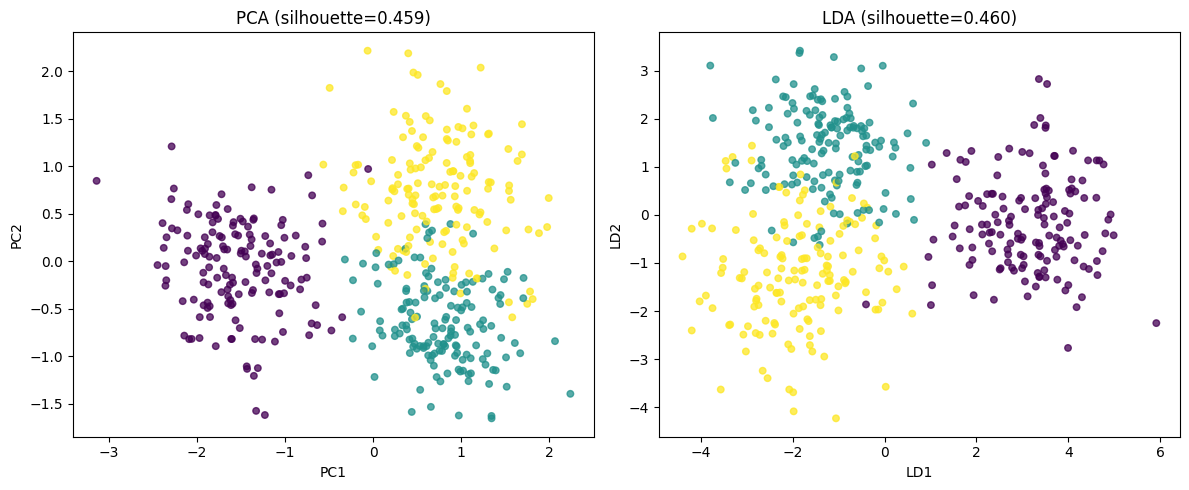

PCA silhouette score: 0.459
LDA silhouette score: 0.460
LDA separates classes better on this labeled dataset


In [186]:
from sklearn.metrics import silhouette_score

if "X3c" not in globals() or "y3c" not in globals():
    from sklearn.datasets import make_blobs
    X3c, y3c = make_blobs(
        n_samples=450,
        centers=[[-2, -1], [2, 2], [0, 4]],
        cluster_std=[1.1, 1.0, 1.2],
        random_state=42,
    )

X3c_scaled = StandardScaler().fit_transform(X3c)

pca_cmp = PCA(n_components=2)
X_pca_cmp = pca_cmp.fit_transform(X3c_scaled)

lda_cmp = LDA(n_components=2)
X_lda_cmp = lda_cmp.fit_transform(X3c_scaled, y3c)

sil_pca = silhouette_score(X_pca_cmp, y3c)
sil_lda = silhouette_score(X_lda_cmp, y3c)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_pca_cmp[:, 0], X_pca_cmp[:, 1], c=y3c, cmap="viridis", s=22, alpha=0.75)
axes[0].set_title(f"PCA (silhouette={sil_pca:.3f})")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[1].scatter(X_lda_cmp[:, 0], X_lda_cmp[:, 1], c=y3c, cmap="viridis", s=22, alpha=0.75)
axes[1].set_title(f"LDA (silhouette={sil_lda:.3f})")
axes[1].set_xlabel("LD1")
axes[1].set_ylabel("LD2")

plt.tight_layout()
plt.show()

print(f"PCA silhouette score: {sil_pca:.3f}")
print(f"LDA silhouette score: {sil_lda:.3f}")
if sil_lda > sil_pca:
    print("LDA separates classes better on this labeled dataset")
else:
    print("PCA is competitive here, but LDA is usually preferable for class separation")

#### 6. Попробуйте изменить параметр degree для полиномиального ядра метода KernelPCA и посмотрите, как это влияет на результат.

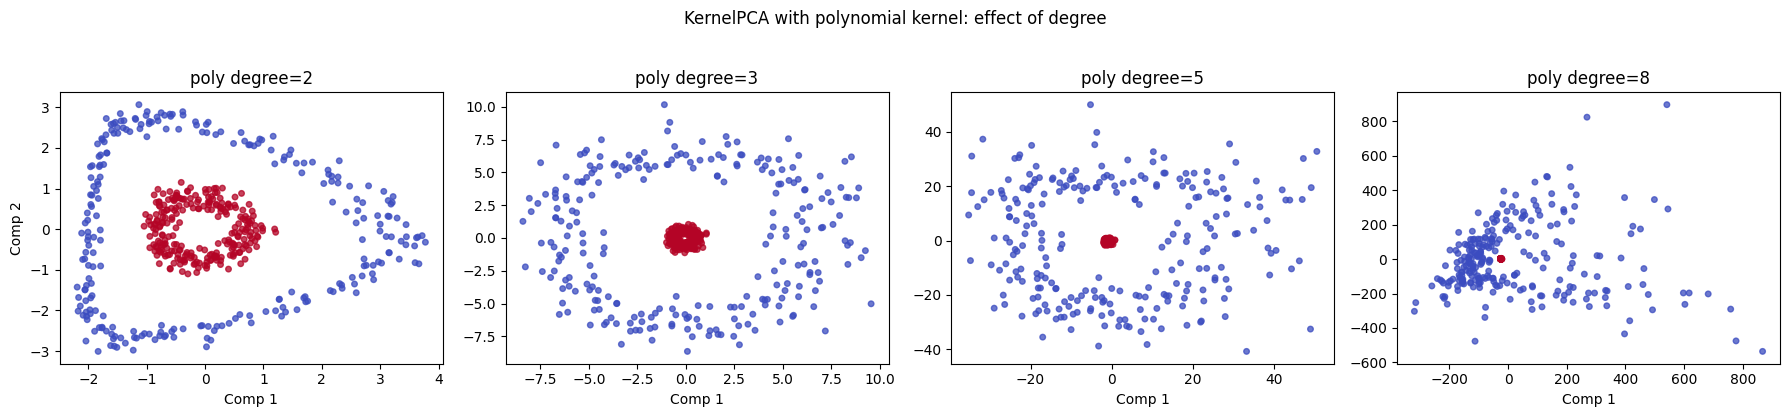

In [187]:
from sklearn.datasets import make_circles
from sklearn.decomposition import KernelPCA

X_poly, y_poly = make_circles(n_samples=500, factor=0.3, noise=0.06, random_state=42)
X_poly_scaled = StandardScaler().fit_transform(X_poly)

degrees = [2, 3, 5, 8]
fig, axes = plt.subplots(1, len(degrees), figsize=(18, 4))

for i, deg in enumerate(degrees):
    kpca_poly = KernelPCA(n_components=2, kernel="poly", degree=deg, gamma=1.0, coef0=1)
    X_poly_kpca = kpca_poly.fit_transform(X_poly_scaled)

    axes[i].scatter(X_poly_kpca[:, 0], X_poly_kpca[:, 1], c=y_poly, cmap="coolwarm", s=16, alpha=0.75)
    axes[i].set_title(f"poly degree={deg}")
    axes[i].set_xlabel("Comp 1")
    if i == 0:
        axes[i].set_ylabel("Comp 2")

plt.suptitle("KernelPCA with polynomial kernel: effect of degree", y=1.03)
plt.tight_layout()
plt.show()

# увеличение степени усиливает нелинейность и может привести к чрезмерному искажению геометрии

#### 7. Примените все три изученных в этой работе метода к датасету для классификации по вашему выбору.

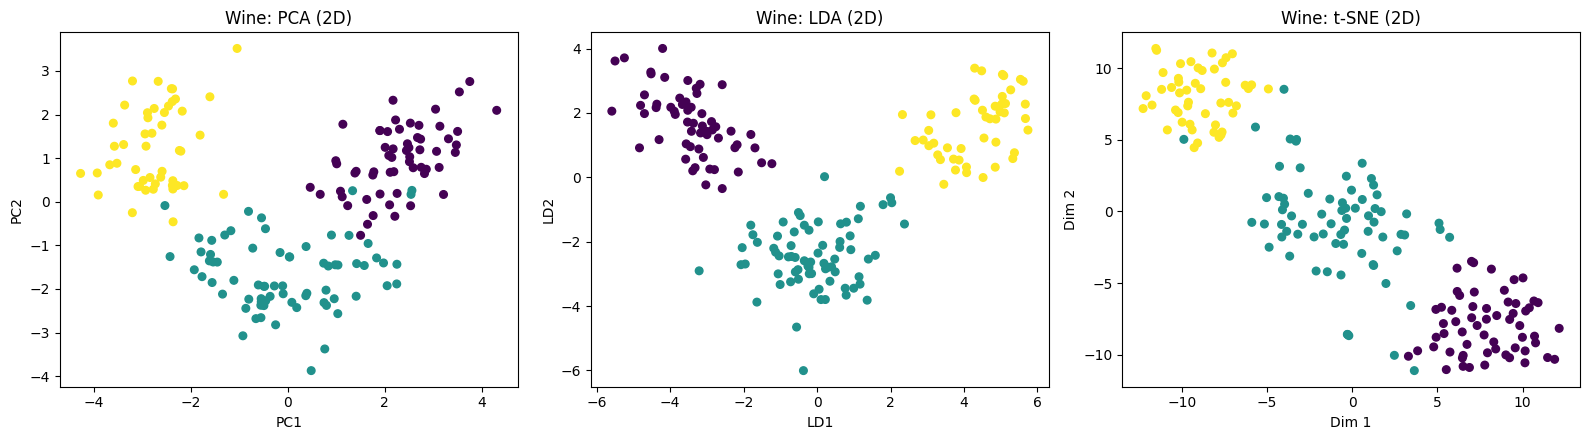

Dataset: .. _wine_dataset:
PCA explained variance (2 comps): 0.554


In [188]:
from sklearn.datasets import load_wine
from sklearn.manifold import TSNE

wine = load_wine()
X_wine = wine.data
y_wine = wine.target
X_wine_scaled = StandardScaler().fit_transform(X_wine)

X_wine_pca2 = PCA(n_components=2, random_state=42).fit_transform(X_wine_scaled)
X_wine_lda2 = LDA(n_components=2).fit_transform(X_wine_scaled, y_wine)
X_wine_tsne2 = TSNE(n_components=2, perplexity=30, random_state=42, init="pca").fit_transform(X_wine_scaled)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].scatter(X_wine_pca2[:, 0], X_wine_pca2[:, 1], c=y_wine, cmap="viridis", s=30)
axes[0].set_title("Wine: PCA (2D)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[1].scatter(X_wine_lda2[:, 0], X_wine_lda2[:, 1], c=y_wine, cmap="viridis", s=30)
axes[1].set_title("Wine: LDA (2D)")
axes[1].set_xlabel("LD1")
axes[1].set_ylabel("LD2")

axes[2].scatter(X_wine_tsne2[:, 0], X_wine_tsne2[:, 1], c=y_wine, cmap="viridis", s=30)
axes[2].set_title("Wine: t-SNE (2D)")
axes[2].set_xlabel("Dim 1")
axes[2].set_ylabel("Dim 2")

plt.tight_layout()
plt.show()

print("Dataset:", wine.DESCR.splitlines()[0])
print("PCA explained variance (2 comps):", PCA(n_components=2).fit(X_wine_scaled).explained_variance_ratio_.sum().round(3))

#### 8. Исследуйте влияние аргумента perplexity на результат работы алгоритма на многомерных данных.

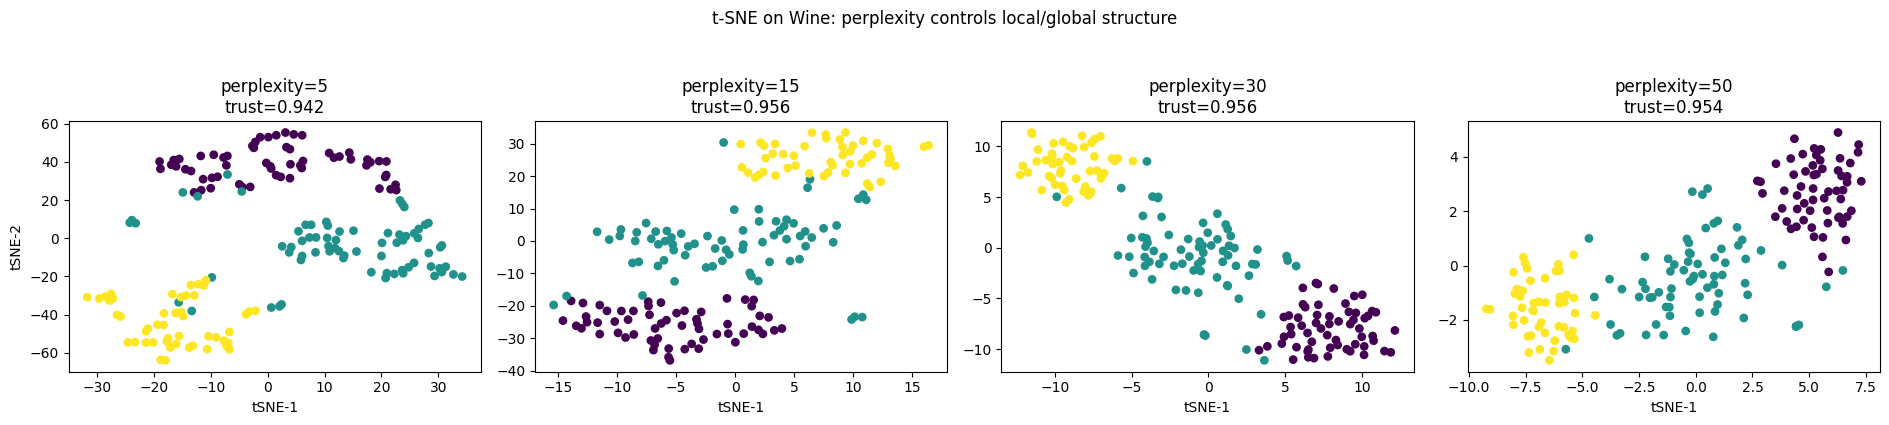

perplexity= 5: trustworthiness=0.942
perplexity=15: trustworthiness=0.956
perplexity=30: trustworthiness=0.956
perplexity=50: trustworthiness=0.954


In [189]:
from sklearn.manifold import TSNE, trustworthiness

wine = load_wine()
Xw = StandardScaler().fit_transform(wine.data)
yw = wine.target

perplexities = [5, 15, 30, 50]
embeddings = {}
trust_scores = {}

fig, axes = plt.subplots(1, len(perplexities), figsize=(19, 4))
for i, p in enumerate(perplexities):
    tsne_p = TSNE(n_components=2, perplexity=p, random_state=42, init="pca")
    X_tsne_p = tsne_p.fit_transform(Xw)
    embeddings[p] = X_tsne_p
    trust_scores[p] = trustworthiness(Xw, X_tsne_p, n_neighbors=10)

    axes[i].scatter(X_tsne_p[:, 0], X_tsne_p[:, 1], c=yw, cmap="viridis", s=28)
    axes[i].set_title(f"perplexity={p}\ntrust={trust_scores[p]:.3f}")
    axes[i].set_xlabel("tSNE-1")
    if i == 0:
        axes[i].set_ylabel("tSNE-2")

plt.suptitle("t-SNE on Wine: perplexity controls local/global structure", y=1.05)
plt.tight_layout()
plt.show()

for p in perplexities:
    print(f"perplexity={p:>2}: trustworthiness={trust_scores[p]:.3f}")

#### 9. Визуализируйте выбранный датасет при помощи разных методов понижения размерности.

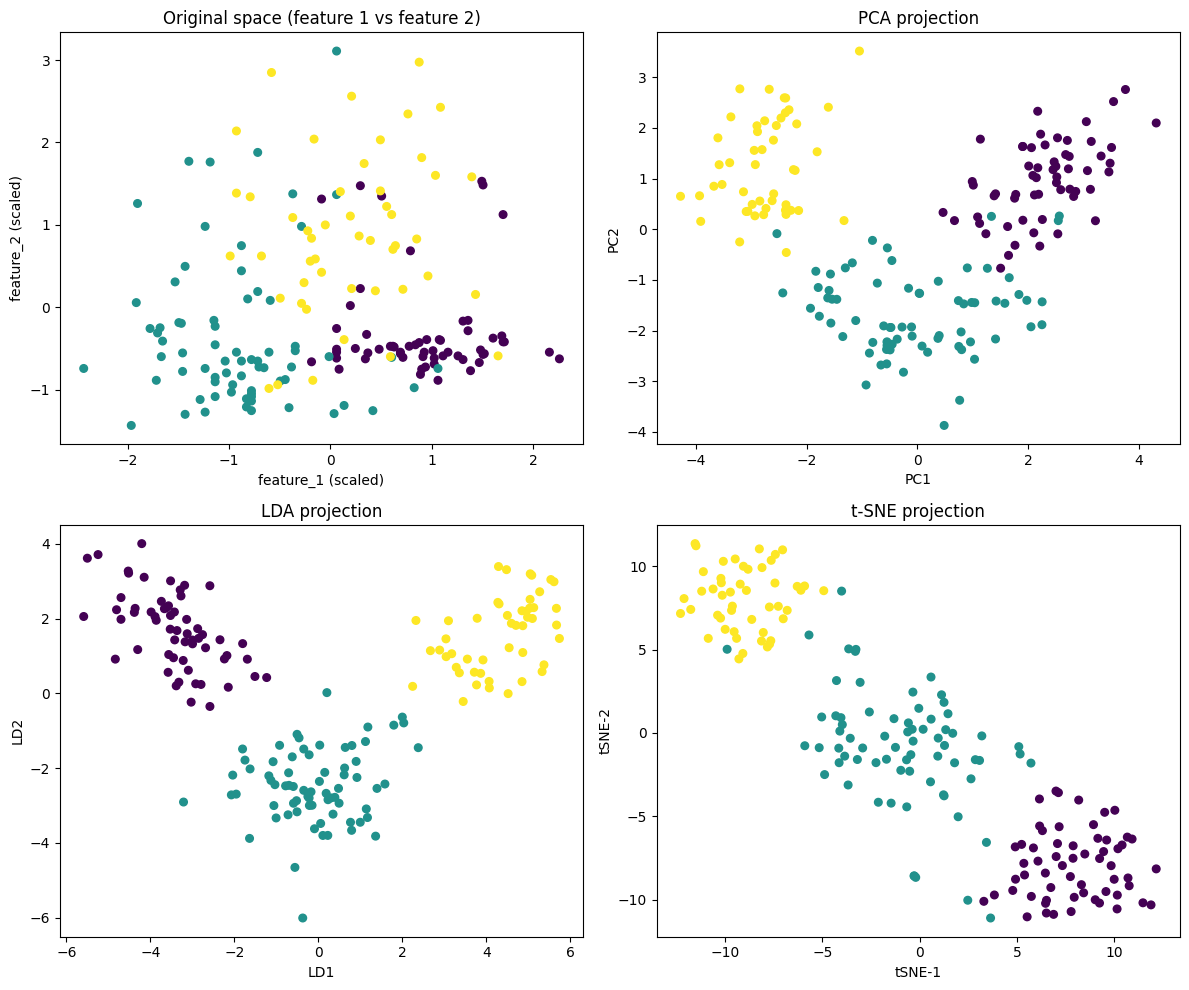

In [190]:
wine = load_wine()
Xv = wine.data
yv = wine.target
Xv_scaled = StandardScaler().fit_transform(Xv)

Xv_pca2 = PCA(n_components=2, random_state=42).fit_transform(Xv_scaled)
Xv_lda2 = LDA(n_components=2).fit_transform(Xv_scaled, yv)
Xv_tsne2 = TSNE(n_components=2, perplexity=30, random_state=42, init="pca").fit_transform(Xv_scaled)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].scatter(Xv_scaled[:, 0], Xv_scaled[:, 1], c=yv, cmap="viridis", s=30)
axes[0, 0].set_title("Original space (feature 1 vs feature 2)")
axes[0, 0].set_xlabel("feature_1 (scaled)")
axes[0, 0].set_ylabel("feature_2 (scaled)")

axes[0, 1].scatter(Xv_pca2[:, 0], Xv_pca2[:, 1], c=yv, cmap="viridis", s=30)
axes[0, 1].set_title("PCA projection")
axes[0, 1].set_xlabel("PC1")
axes[0, 1].set_ylabel("PC2")

axes[1, 0].scatter(Xv_lda2[:, 0], Xv_lda2[:, 1], c=yv, cmap="viridis", s=30)
axes[1, 0].set_title("LDA projection")
axes[1, 0].set_xlabel("LD1")
axes[1, 0].set_ylabel("LD2")

axes[1, 1].scatter(Xv_tsne2[:, 0], Xv_tsne2[:, 1], c=yv, cmap="viridis", s=30)
axes[1, 1].set_title("t-SNE projection")
axes[1, 1].set_xlabel("tSNE-1")
axes[1, 1].set_ylabel("tSNE-2")

plt.tight_layout()
plt.show()

#### 10. Сравните все три алгоритма классификации по метрике доли объясненной дисперсии. Выберите для каждого метода оптимальное количество кластеров по методу локтя.

PCA explained variance (2D): 0.554
LDA explained variance (2D): 1.000
t-SNE trustworthiness (2D): 0.956  # t-SNE has no explained variance metric


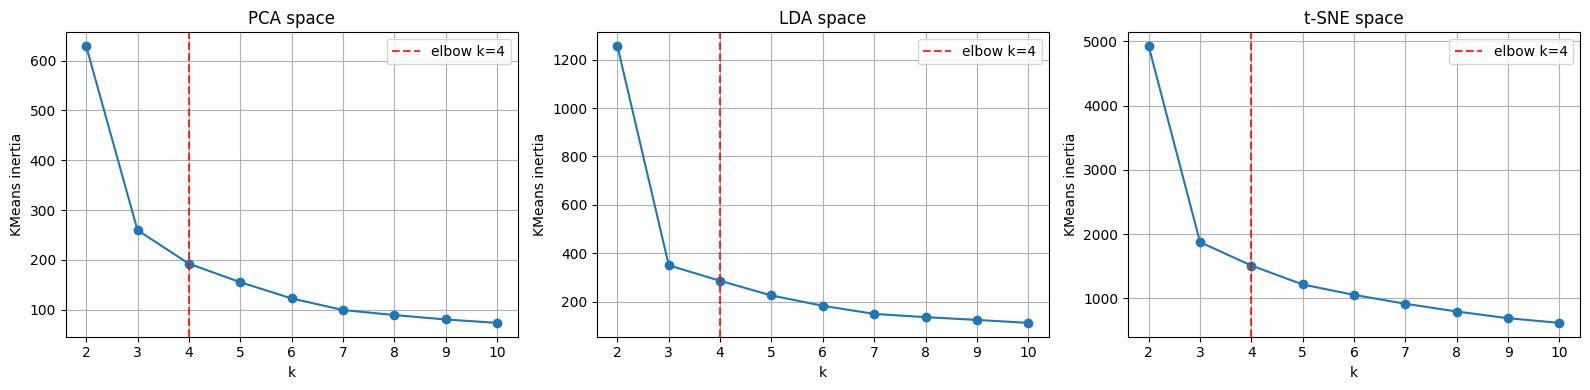

Estimated optimal k by elbow in PCA space:  4
Estimated optimal k by elbow in LDA space:  4
Estimated optimal k by elbow in t-SNE space: 4


In [191]:
from sklearn.cluster import KMeans

wine = load_wine()
X_cmp = StandardScaler().fit_transform(wine.data)
y_cmp = wine.target

X_pca = PCA(n_components=2, random_state=42).fit_transform(X_cmp)
X_lda = LDA(n_components=2).fit_transform(X_cmp, y_cmp)
X_tsne = TSNE(n_components=2, perplexity=30, random_state=42, init="pca").fit_transform(X_cmp)

pca_var = PCA(n_components=2, random_state=42).fit(X_cmp).explained_variance_ratio_.sum()
lda_model = LDA(n_components=2).fit(X_cmp, y_cmp)
lda_var = lda_model.explained_variance_ratio_.sum()
tsne_trust = trustworthiness(X_cmp, X_tsne, n_neighbors=10)

print(f"PCA explained variance (2D): {pca_var:.3f}")
print(f"LDA explained variance (2D): {lda_var:.3f}")
print(f"t-SNE trustworthiness (2D): {tsne_trust:.3f}  # t-SNE has no explained variance metric")


def elbow_inertia(embedding, k_values):
    inertias = []
    for k in k_values:
        km = KMeans(n_clusters=k, random_state=42, n_init=20)
        km.fit(embedding)
        inertias.append(km.inertia_)
    return np.array(inertias)

k_values = np.arange(2, 11)
inertia_pca = elbow_inertia(X_pca, k_values)
inertia_lda = elbow_inertia(X_lda, k_values)
inertia_tsne = elbow_inertia(X_tsne, k_values)


def pick_elbow(inertias, k_values_local):
    second_diff = np.diff(inertias, n=2)
    elbow_idx = np.argmax(np.abs(second_diff)) + 2
    return int(k_values_local[elbow_idx])

k_pca = pick_elbow(inertia_pca, k_values)
k_lda = pick_elbow(inertia_lda, k_values)
k_tsne = pick_elbow(inertia_tsne, k_values)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, inertias, title, k_star in [
    (axes[0], inertia_pca, "PCA space", k_pca),
    (axes[1], inertia_lda, "LDA space", k_lda),
    (axes[2], inertia_tsne, "t-SNE space", k_tsne),
]:
    ax.plot(k_values, inertias, marker="o")
    ax.axvline(k_star, color="red", linestyle="--", alpha=0.8, label=f"elbow k={k_star}")
    ax.set_title(title)
    ax.set_xlabel("k")
    ax.set_ylabel("KMeans inertia")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

print(f"Estimated optimal k by elbow in PCA space:  {k_pca}")
print(f"Estimated optimal k by elbow in LDA space:  {k_lda}")
print(f"Estimated optimal k by elbow in t-SNE space: {k_tsne}")

#### 11. Повторите измерение метрики, но уже после разбиения выборки на тестовую и обучающую. Сравните долю объясненной дисперсии на тестовой выборке.

In [192]:
from sklearn.model_selection import train_test_split

wine = load_wine()
X_full = wine.data
y_full = wine.target

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.3, random_state=42, stratify=y_full
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca_tt = PCA(n_components=2, random_state=42)
X_train_pca = pca_tt.fit_transform(X_train_scaled)
X_test_pca = pca_tt.transform(X_test_scaled)

pca_train_evr = pca_tt.explained_variance_ratio_.sum()
pca_test_preserved = np.var(X_test_pca, axis=0, ddof=1).sum() / np.var(X_test_scaled, axis=0, ddof=1).sum()

lda_tt = LDA(n_components=2)
X_train_lda = lda_tt.fit_transform(X_train_scaled, y_train)
X_test_lda = lda_tt.transform(X_test_scaled)

lda_train_evr = lda_tt.explained_variance_ratio_.sum()
lda_test_preserved = np.var(X_test_lda, axis=0, ddof=1).sum() / np.var(X_test_scaled, axis=0, ddof=1).sum()

tsne_train = TSNE(n_components=2, perplexity=30, random_state=42, init="pca")
X_train_tsne = tsne_train.fit_transform(X_train_scaled)
tsne_train_trust = trustworthiness(X_train_scaled, X_train_tsne, n_neighbors=10)

tsne_test = TSNE(n_components=2, perplexity=30, random_state=42, init="pca")
X_test_tsne = tsne_test.fit_transform(X_test_scaled)
tsne_test_trust = trustworthiness(X_test_scaled, X_test_tsne, n_neighbors=10)

print("Train metrics")
print(f"PCA explained variance (train): {pca_train_evr:.3f}")
print(f"LDA explained variance (train): {lda_train_evr:.3f}")
print(f"t-SNE trustworthiness (train): {tsne_train_trust:.3f}")

print("\nTest metrics")
print(f"PCA preserved variance on test: {pca_test_preserved:.3f}")
print(f"LDA preserved variance on test: {lda_test_preserved:.3f}")
print(f"t-SNE trustworthiness (test): {tsne_test_trust:.3f}")

# В случае t-SNE значения на обучающей и тестовой выборках не являются прямым аналогом объясненной дисперсии,
# поскольку t-SNE — нелинейный и непараметрический алгоритм

Train metrics
PCA explained variance (train): 0.549
LDA explained variance (train): 1.000
t-SNE trustworthiness (train): 0.959

Test metrics
PCA preserved variance on test: 0.569
LDA preserved variance on test: 1.333
t-SNE trustworthiness (test): 0.977
